In [1]:
from datasets import Dataset, DatasetDict, load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import re



c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("7Xan7der7/us_airline_sentiment")

In [3]:
df = pd.DataFrame(dataset["train"])

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,5.703060e+17,neutral,1.0000,None,NaN,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,None,2/24/2015 11:35,None,Eastern Time (US & Canada)
1,5.703010e+17,positive,0.3486,None,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,None,2/24/2015 11:15,None,Pacific Time (US & Canada)
2,5.703010e+17,neutral,0.6837,None,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,None,2/24/2015 11:15,Lets Play,Central Time (US & Canada)
3,5.703010e+17,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,None,2/24/2015 11:15,None,Pacific Time (US & Canada)
4,5.703010e+17,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,None,2/24/2015 11:14,None,Pacific Time (US & Canada)


In [4]:
print(f"Colonnes disponibles : {df.columns.tolist()}")


Colonnes disponibles : ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'name', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


In [5]:
airline_counts = df['airline'].value_counts()
print(airline_counts)

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64


In [6]:
print(df.describe())


           tweet_id  airline_sentiment_confidence  negativereason_confidence  \
count  1.464000e+04                  14640.000000               10522.000000   
mean   5.692184e+17                      0.900169                   0.638298   
std    7.791092e+14                      0.162830                   0.330440   
min    5.675880e+17                      0.335000                   0.000000   
25%    5.685590e+17                      0.692300                   0.360600   
50%    5.694780e+17                      1.000000                   0.670600   
75%    5.698902e+17                      1.000000                   1.000000   
max    5.703110e+17                      1.000000                   1.000000   

       retweet_count  
count   14640.000000  
mean        0.082650  
std         0.745778  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max        44.000000  


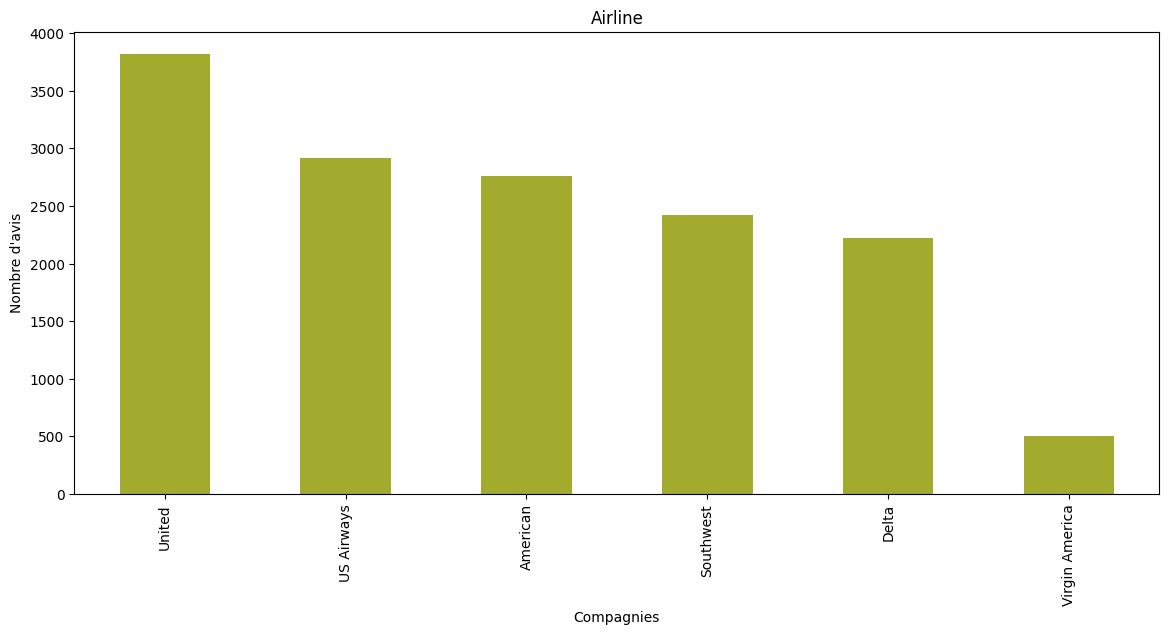

In [7]:
plt.figure(figsize=(14, 6))
airline_counts.plot(kind="bar", color="#A3AB2E")
plt.title("Airline")
plt.ylabel("Nombre d'avis")
plt.xlabel("Compagnies")
plt.show()


In [8]:
import emoji

def datacleaning(txt):
    if not isinstance(txt, str):
        return ""
    
    txt = txt.lower()
    
    # Remove URLs
    txt = re.sub(r'https?://\S+|www\.\S+', '', txt)
    
    # Remove mentions @user
    txt = re.sub(r'@\w+', '', txt)
    
    # Remove hashtags
    txt = re.sub(r'#\w+', '', txt)
    
    # Remove punctuation and special characters, keep emojis
    all_chars = []
    for char in txt:
        if char.isalnum() or char.isspace() or emoji.is_emoji(char):
            all_chars.append(char)
    txt = ''.join(all_chars)
    
    # Remove multiple spaces
    txt = re.sub(r'\s+', ' ', txt)
    
    # Remove leading and trailing spaces
    txt = txt.strip()
    
    return txt


In [9]:
data_clean = df.copy()

data_clean["text_clean"] = data_clean["text"].apply(datacleaning)

In [10]:
initial_count = len(data_clean)
data_clean = data_clean.drop_duplicates(subset=['text_clean'])    
duplicate_count = initial_count - len(data_clean)

In [11]:
df_clean = data_clean.dropna(subset=['text_clean', 'airline_sentiment'])


In [12]:
print(f"Doublons supprimes : {duplicate_count}")

print(f"Exemple de texte nettoye :\n{df_clean['text_clean'].iloc[0]}")



Doublons supprimes : 446
Exemple de texte nettoye :
what said


In [13]:
label_map = {'negative': 0,
              'neutral': 1, 
             'positive': 2
             }

df_clean['label'] = df_clean['airline_sentiment'].map(label_map)

In [14]:
df_clean.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,text_clean,label
0,5.703060e+17,neutral,1.0000,None,NaN,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,None,2/24/2015 11:35,None,Eastern Time (US & Canada),what said,1
1,5.703010e+17,positive,0.3486,None,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,None,2/24/2015 11:15,None,Pacific Time (US & Canada),plus youve added commercials to the experience...,2
2,5.703010e+17,neutral,0.6837,None,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,None,2/24/2015 11:15,Lets Play,Central Time (US & Canada),i didnt today must mean i need to take another...,1
3,5.703010e+17,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,None,2/24/2015 11:15,None,Pacific Time (US & Canada),its really aggressive to blast obnoxious enter...,0
4,5.703010e+17,negative,1.0000,Can't Tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,None,2/24/2015 11:14,None,Pacific Time (US & Canada),and its a really big bad thing about it,0


In [15]:

from sentence_transformers import SentenceTransformer

sentence_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Génération des embeddings par batch pour optimiser la mémoire
batch_size = 32
embeddings = []

for i in range(0, len(df_clean), batch_size):
    batch_texts = df_clean['text_clean'].iloc[i:i+batch_size].tolist()
    batch_embeddings = sentence_model.encode(batch_texts, show_progress_bar=False)
    embeddings.extend(batch_embeddings)

df_clean['embedding'] = [emb.tolist() for emb in embeddings]

print("=== Génération des embeddings terminée ===")
print(f"Dimension des embeddings : {embeddings[0].shape}")
print(f"Nombre total d'embeddings générés : {len(embeddings)}")

c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aamir\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


=== Génération des embeddings terminée ===
Dimension des embeddings : (384,)
Nombre total d'embeddings générés : 14194


In [16]:
# stockage 
import chromadb
chromadb_client = chromadb.PersistentClient(path="../data/embeddings")

def create_chroma_collection(collection_name, df_subset):
    """Crée une collection ChromaDB avec les embeddings"""
    try:
        chromadb_client.delete_collection(collection_name)
    except:
        pass

    collection = chromadb_client.get_or_create_collection(name=collection_name)

    # Ajout des embeddings
    batch_size = 100
    for i in range(0, len(df_subset), batch_size):
        batch = df_subset.iloc[i:i+batch_size]

        documents = batch['text_clean'].tolist()
        embeddings_batch = batch['embedding'].tolist()
        metadatas = [
            {
                'label': int(row['label']),
                'sentiment': row['airline_sentiment'],
                'airline': row['airline'],
                'id': idx + i
            }
            for idx, (_, row) in enumerate(batch.iterrows())
        ]
        ids = [str(idx + i) for idx in range(len(batch))]

        collection.add(
            documents=documents,
            embeddings=embeddings_batch,
            metadatas=metadatas,
            ids=ids
        )

    return collection


In [17]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.3,
    stratify=df_clean['label'],
    random_state=42

)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

In [18]:

train_collection = create_chroma_collection("train_data", train_df)
test_collection = create_chroma_collection("test_data", test_df)

print(f"Collection 'train_data' créée avec {train_collection.count()} documents")
print(f"Collection 'test_data' créée avec {test_collection.count()} documents")

# Sauvegarde
print("ChromaDB persisté sur disque")

Collection 'train_data' créée avec 9935 documents
Collection 'test_data' créée avec 2130 documents
ChromaDB persisté sur disque


In [20]:
# Exemple de requête sur ChromaDB
query_text = "its really aggressive to blast obnoxious enter."
query_embedding = sentence_model.encode([query_text])[0].tolist()

results = test_collection.query(
    query_embeddings=[query_embedding],
    n_results=3
)

print("=== Exemple de requête de similarité ===")
print(f"Requête : '{query_text}'")
print("\nDocuments similaires trouvés :")
for i, (doc, metadata) in enumerate(zip(results['documents'][0], results['metadatas'][0]), 1):
    print(f"\n{i}. {doc[:100]}...")
    print(f"   Sentiment: {metadata['sentiment']}")
    print(f"   Compagnie: {metadata['airline']}")

=== Exemple de requête de similarité ===
Requête : 'its really aggressive to blast obnoxious enter.'

Documents similaires trouvés :

1. freakin...
   Sentiment: negative
   Compagnie: United

2. lauren im screakjmf...
   Sentiment: neutral
   Compagnie: Southwest

3. and this asshole cut in front of me your system blows...
   Sentiment: negative
   Compagnie: Southwest


In [ ]:
def load_embeddings_from_collection(collection):
    docs = collection.get(include=['embeddings', 'metadatas'])
    embeddings = docs['embeddings']
    labels = [m['label'] for m in docs['metadatas']]
    return embeddings, labels

train_embeddings, train_labels = load_embeddings_from_collection(train_collection)
test_embeddings, test_labels = load_embeddings_from_collection(test_collection)


In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb

#  Random Forest
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
rf_clf.fit(train_embeddings, train_labels)

#  XGBoost

#   verbose=-1
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1, objective='multi:softmax', 
    num_class=3, eval_metric='mlogloss', use_label_encoder=False, random_state=42
)
xgb_clf.fit(train_embeddings, train_labels)

#  LightGBM
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200, max_depth=20, learning_rate=0.05, num_leaves=50, random_state=42
)
lgb_clf.fit(train_embeddings, train_labels)

# SVM
svm_clf = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_clf.fit(train_embeddings, train_labels)


c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [14:48:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97920
[LightGBM] [Info] Number of data points in the train set: 9935, number of used features: 384
[LightGBM] [Info] Start training from score -0.448870
[LightGBM] [Info] Start training from score -1.571903
[LightGBM] [Info] Start training from score -1.870796


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

models = {
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf,
    "LightGBM": lgb_clf,
    "SVM": svm_clf
}

# Binariser les labels pour ROC-AUC
test_labels_bin = label_binarize(test_labels, classes=[0,1,2])

results = {}

for name, model in models.items():
    preds = model.predict(test_embeddings)
    if hasattr(model, "predict_proba"):
        preds_proba = model.predict_proba(test_embeddings)
    else:  # SVM
        preds_proba = model.decision_function(test_embeddings)
    
    acc = accuracy_score(test_labels, preds)
    f1 = f1_score(test_labels, preds, average='macro')
    try:
        roc_auc = roc_auc_score(test_labels_bin, preds_proba, multi_class='ovr')
    except:
        roc_auc = None  # si le modèle ne supporte pas probas
    results[name] = {"Accuracy": acc, "F1-macro": f1, "ROC-AUC": roc_auc}

# Affichage des résultats
for name, metrics in results.items():
    print(f"=== {name} ===")
    print(metrics)


c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Random Forest ===
{'Accuracy': 0.7643192488262911, 'F1-macro': 0.6376188704259332, 'ROC-AUC': 0.8972254972019078}
=== XGBoost ===
{'Accuracy': 0.8028169014084507, 'F1-macro': 0.7282642485013602, 'ROC-AUC': 0.914393129553796}
=== LightGBM ===
{'Accuracy': 0.807981220657277, 'F1-macro': 0.7353033108179906, 'ROC-AUC': 0.9161906022967535}
=== SVM ===
{'Accuracy': 0.8244131455399061, 'F1-macro': 0.7621878709739905, 'ROC-AUC': 0.926719650257826}


c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


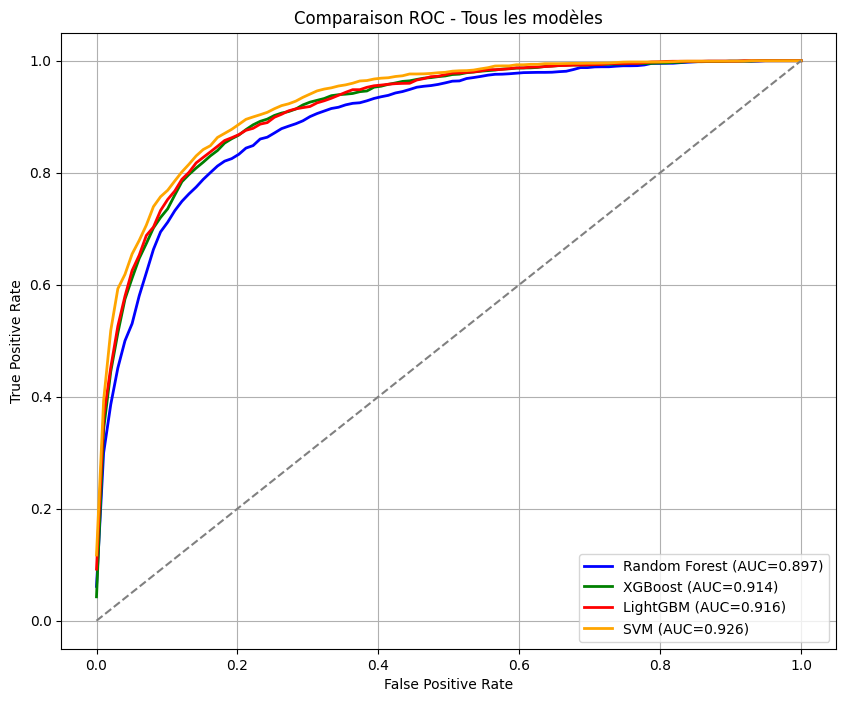

In [28]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Binariser les labels
classes = [0,1,2]  # adapte selon tes labels
y_test_bin = label_binarize(test_labels, classes=classes)
n_classes = y_test_bin.shape[1]

# Couleurs et styles pour chaque modèle
model_colors = {
    "Random Forest": 'blue',
    "XGBoost": 'green',
    "LightGBM": 'red',
    "SVM": 'orange'
}

plt.figure(figsize=(10,8))

for name, model in models.items():
    # Prédire probabilités
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(test_embeddings)
    else:
        y_prob = model.decision_function(test_embeddings)
        if y_prob.ndim == 1:  # binaire
            y_prob = np.vstack([1 - y_prob, y_prob]).T

    # Calcul AUC pour chaque classe
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Moyenne macro pour le modèle
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(mean_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(mean_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    mean_auc = auc(mean_fpr, mean_tpr)
    
    # Tracer la courbe ROC moyenne
    plt.plot(mean_fpr, mean_tpr, color=model_colors[name], lw=2,
             label=f"{name} (AUC={mean_auc:.3f})")

plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparaison ROC - Tous les modèles")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



=== Tableau comparatif des modèles ===
               Accuracy  F1-macro   ROC-AUC
Random Forest  0.764319  0.637619  0.897225
XGBoost        0.802817  0.728264  0.914393
LightGBM       0.807981  0.735303  0.916191
SVM            0.824413  0.762188  0.926720


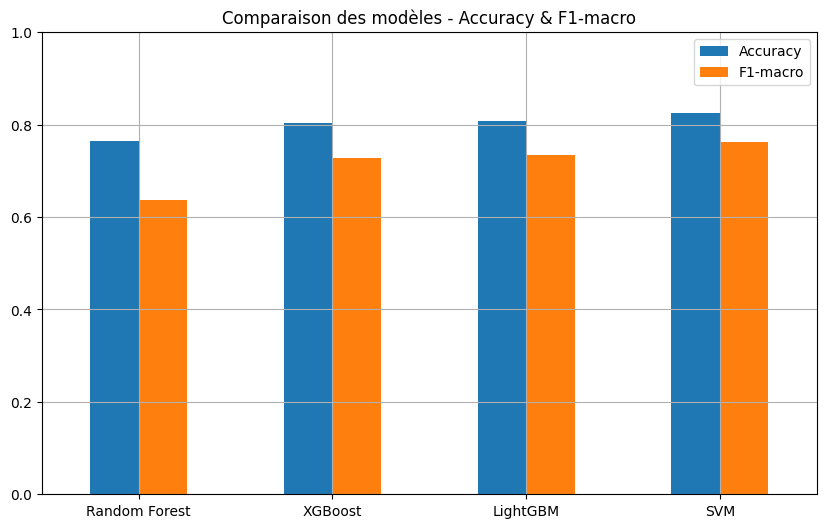

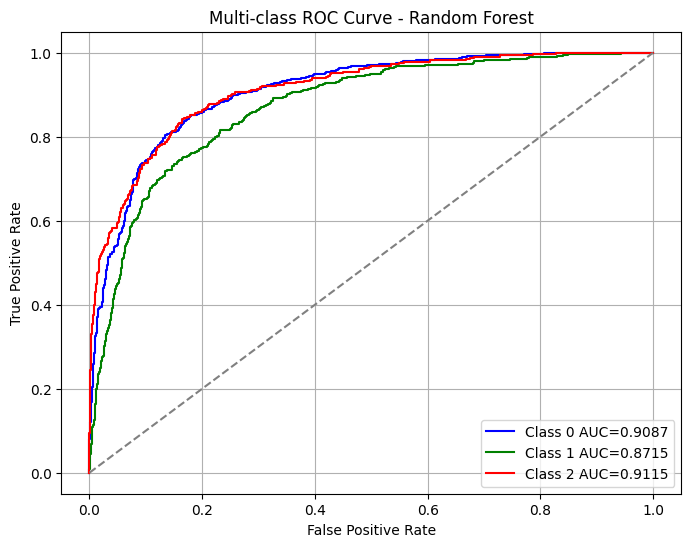

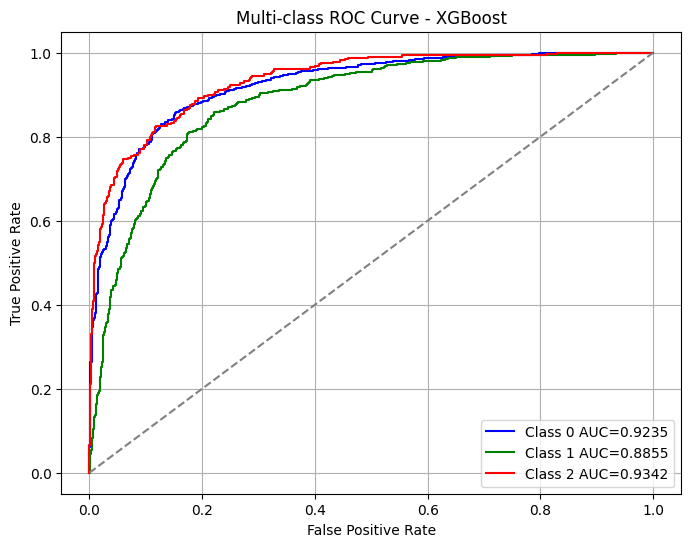

c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


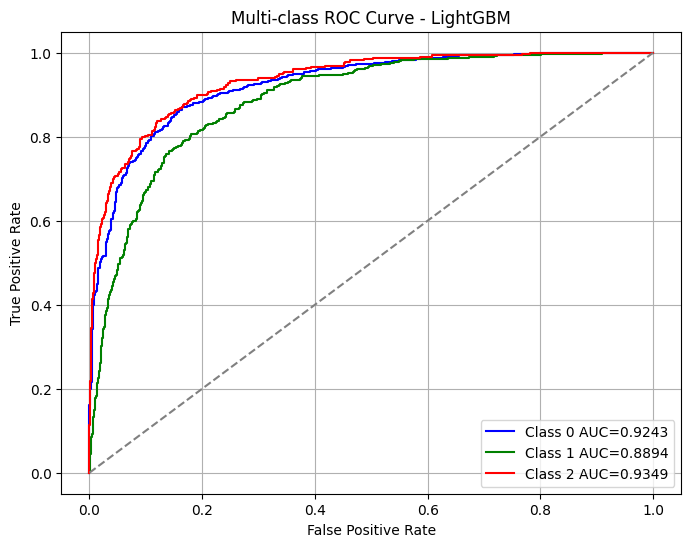

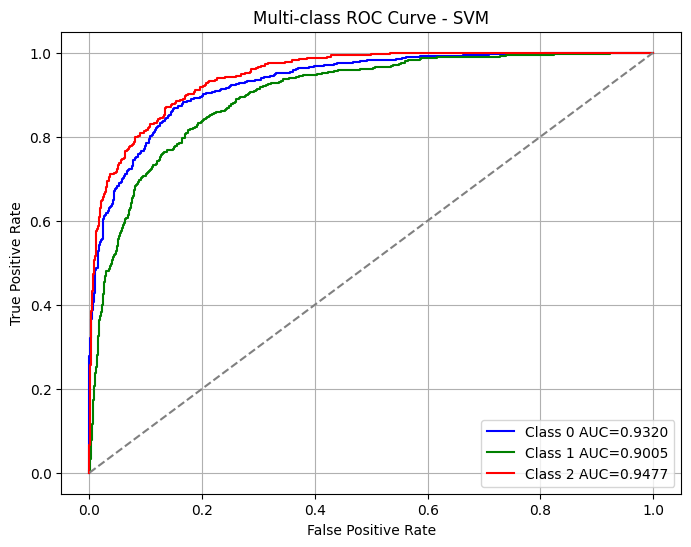

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

df_results = pd.DataFrame(results).T
print("\n=== Tableau comparatif des modèles ===")
print(df_results)

df_results[['Accuracy','F1-macro']].plot(kind='bar', figsize=(10,6))
plt.title("Comparaison des modèles - Accuracy & F1-macro")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


classes = [0,1,2]  
n_classes = len(classes)

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        preds_proba = model.predict_proba(test_embeddings)
    else:
        preds_proba = model.decision_function(test_embeddings)
        if preds_proba.ndim == 1:
            preds_proba = np.vstack([1 - preds_proba, preds_proba]).T
    
    y_test_bin = label_binarize(test_labels, classes=classes)
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], preds_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    plt.figure(figsize=(8,6))
    colors = ['blue','green','red']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, label=f"Class {classes[i]} AUC={roc_auc[i]:.4f}")
    plt.plot([0,1], [0,1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-class ROC Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
voting_clf = VotingClassifier(
    estimators=[('rf', rf_clf), ('xgb', xgb_clf), ('lgb', lgb_clf), ('svm', svm_clf)],
    voting='soft'  
)
voting_clf.fit(train_embeddings, train_labels)
voting_preds = voting_clf.predict(test_embeddings)

acc = accuracy_score(test_labels, voting_preds)
f1 = f1_score(test_labels, voting_preds, average='macro')
print(f"Voting Classifier - Accuracy: {acc:.3f}, F1-macro: {f1:.3f}")


c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [14:55:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040878 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97920
[LightGBM] [Info] Number of data points in the train set: 9935, number of used features: 384
[LightGBM] [Info] Start training from score -0.448870
[LightGBM] [Info] Start training from score -1.571903
[LightGBM] [Info] Start training from score -1.870796


c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Voting Classifier - Accuracy: 0.811, F1-macro: 0.741
